# tap.metallique~ / tap.palme~ — the diffuseurs, driven

The Ondes Martenot does not have a loudspeaker, it has a rack of them, and choosing between them
is part of playing the instrument. Two of Martenot's resonating *diffuseurs* are modelled here:

- the **métallique** (1944–45, patented 1947), a **gong** driven by a motor transducer, and
- the **palme** (1949–50), an electromagnet driving **twelve** metal strings on a soundboard.

Najnudel, Hélie, Roze & Boutin (*"Simulation of an ondes Martenot circuit"*, IEEE/ACM TASLP 28,
2020) name the diffuseur as the stage that "converts the electrical waveform into sound and in
turn modifies its spectral content"; Wijnand, Boutin, Jossic & Maniguet (Forum Acusticum 2023)
describe the instruments and characterize the transducer.

Two things about this kernel are worth stating before any plot:

**They are driven, not struck.** `garden.h`'s modal machinery carries over — mode ratios, doublet
splitting, per-mode decay — but its strike envelopes do not. There is no trigger here. The input
excites the body continuously and the body rings at its own rates.

**The bodies are recreations.** No ondes-specific modal measurement exists in any of the sources,
so the mode data is Fletcher & Rossing's general physics: the free circular plate's transverse
ratios for the gong, the harmonic series for the strings. Unlike `touche.ipynb`, which reproduces
a published table, this notebook cannot check the object against the instrument. What it *can*
check is that the maths underneath is honest — and that is what everything below measures.

Every number here comes out of the shipping C++ through `tools/capi`; nothing is re-implemented
in Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.4),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

# Fletcher & Rossing, The Physics of Musical Instruments, 2nd ed. — the free circular plate's
# transverse modes at Poisson 0.3 (Rayleigh's classical Chladni set), referenced to (2,0).
PLATE_RATIO = np.array([1.000, 1.730, 2.328, 3.910, 4.110, 6.300, 6.710, 7.340])

def spectrum(x, n_from=None):
    x = np.asarray(x, dtype=float)
    if n_from is None:
        n_from = len(x) // 2
    seg = x[n_from:]
    win = np.hanning(len(seg))
    mag = np.abs(np.fft.rfft(seg * win)) / (len(seg) / 4)
    return np.fft.rfftfreq(len(seg), 1 / sr), mag

def bin_at(x, hz, n_from=None):
    # single-bin magnitude by Goertzel, so a measurement never depends on FFT bin alignment
    x = np.asarray(x, dtype=float)
    if n_from is None:
        n_from = len(x) // 2
    seg = x[n_from:]
    w = 2 * np.pi * hz / sr
    c = 2 * np.cos(w)
    s1 = s2 = 0.0
    for v in seg:
        s1, s2 = v + c * s1 - s2, s1
    return np.sqrt(max(0.0, s1 * s1 + s2 * s2 - c * s1 * s2)) * 2 / len(seg)

print("kernel reached through the C ABI:", tap.Metallique, tap.Palme)

kernel reached through the C ABI: <class 'taptools_py.Metallique'> <class 'taptools_py.Palme'>


## 1 · Where the gong's modes land, and how much of it each carries

The plate is eight modes, each split into a slowly beating doublet (1.5 cents) and nudged a few
cents off the textbook ratio by a fixed per-index hash — a real plate is not a table. The weights
are chosen to sum to exactly 1, which is the whole boundedness argument: every resonator in the
bank has unit peak gain, so a weighted sum of them cannot amplify what drives it.

In [2]:
gong = tap.Metallique(sr, pitch_hz=180.0, decay=6.0, tilt=1.0, brightness=1.0,
                      drive=1.0, asymmetry=0.0, saturation=0.0, mix=100.0)
hz, weight = gong.modes()

print(f"{'mode':>5} {'published':>10} {'kernel':>10} {'cents off':>10} {'weight':>9}")
for i, (f, w) in enumerate(zip(hz, weight)):
    got = f / hz[0]
    cents = 1200 * np.log2(got / PLATE_RATIO[i])
    print(f"{i:5d} {PLATE_RATIO[i]:10.3f} {got:10.3f} {cents:9.2f}  {w:9.4f}")
print(f"\nsum of weights: {weight.sum():.12f}")

 mode  published     kernel  cents off    weight
    0      1.000      1.000      0.00     0.3000
    1      1.730      1.727     -3.43     0.2200
    2      2.328      2.323     -3.70     0.1600
    3      3.910      3.909     -0.62     0.1200
    4      4.110      4.118      3.33     0.0800
    5      6.300      6.312      3.25     0.0500
    6      6.710      6.707     -0.78     0.0400
    7      7.340      7.357      3.92     0.0300

sum of weights: 1.000000000000


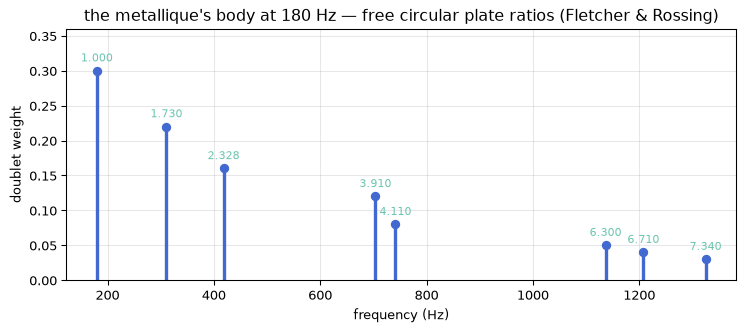

In [3]:
fig, ax = plt.subplots()
ax.vlines(hz, 0, weight, color=C[0], lw=2.5)
ax.plot(hz, weight, "o", color=C[0], ms=6)
for i, (f, w) in enumerate(zip(hz, weight)):
    ax.annotate(f"{PLATE_RATIO[i]:.3f}", (f, w), textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=8, color=C[3])
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("doublet weight")
ax.set_title("the metallique's body at 180 Hz — free circular plate ratios (Fletcher & Rossing)")
ax.set_ylim(0, 0.36)
plt.show()

## 2 · The resonator is bounded, and that is not an accident

Each mode is the constant-peak-gain two-pole resonator — zeros at ±1, `b0 = (1 − R²)/2`
(Steiglitz; Smith, *Introduction to Digital Filters*). Its peak magnitude is 1 for **any** pole
radius, so a bank of weighted modes needs no limiter after it and the zeros put exact nulls at DC
and Nyquist, so it needs no DC blocker either.

Measured below by sweeping a sine through the whole plate: the response has the eight resonances
in it, and the peak output never exceeds a bounded input.

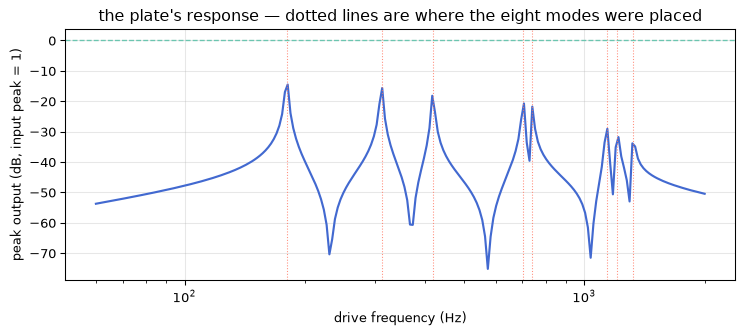

largest peak output for a unit-amplitude drive: 0.1880
The weights guarantee a bound of 1.0; the measured peak sits well inside it, because a
resonance takes a while to build and the weight of any single mode is a fraction of the sum.


In [4]:
probe_hz = np.geomspace(60.0, 2000.0, 220)
resp = []
for f in probe_hz:
    g = tap.Metallique(sr, pitch_hz=180.0, decay=1.2, tilt=1.0, brightness=1.0,
                       drive=1.0, asymmetry=0.0, saturation=0.0, mix=100.0)
    n = int(sr * 1.2)
    t = np.arange(n) / sr
    y = g.process(np.sin(2 * np.pi * f * t))
    resp.append(np.abs(y[int(sr * 0.9):]).max())
resp = np.array(resp)

fig, ax = plt.subplots()
ax.semilogx(probe_hz, 20 * np.log10(resp), color=C[0], lw=1.6)
for i, f in enumerate(hz):
    ax.axvline(f, color=C[2], lw=0.8, ls=":", alpha=0.8)
ax.set_xlabel("drive frequency (Hz)"); ax.set_ylabel("peak output (dB, input peak = 1)")
ax.set_title("the plate's response — dotted lines are where the eight modes were placed")
ax.axhline(0, color=C[3], lw=1.0, ls="--")
plt.show()

print(f"largest peak output for a unit-amplitude drive: {resp.max():.4f}")
print("The weights guarantee a bound of 1.0; the measured peak sits well inside it, because a")
print("resonance takes a while to build and the weight of any single mode is a fraction of the sum.")

## 3 · The transducer, and the one part of it with physics behind it

Wijnand et al.'s point is that the early diffuseurs use a **moving-iron** driver whose operating
principle is inherently nonlinear — Thiele–Small does not describe it — so a diffuseur modelled
as a pure resonator is missing a documented stage.

What the kernel models is the *principle*, not a fit. In a moving-iron motor the force follows the
square of the gap flux, so with a bias current I₀ and signal i the force carries a term in
(I₀ + i)²: the residual i² is a second harmonic growing with drive. For a sine of amplitude A and
asymmetry a, that predicts a second harmonic at exactly **a·A/2** relative to the fundamental —
and nothing at the third. Measured against that prediction:

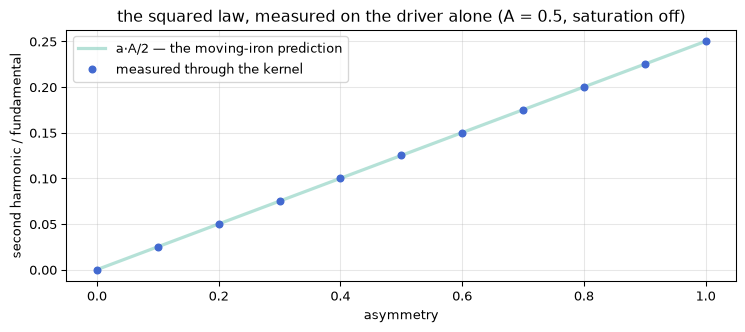

largest departure from the prediction: 1.37e-04
largest third harmonic:                2.75e-09
A squared term makes a second harmonic and nothing else — which is the point of it
being a squared term rather than an offset pushed through a general clipper.


In [5]:
amp = 0.5
asyms = np.linspace(0.0, 1.0, 11)
ratio, third = [], []
for a in asyms:
    drv = tap.Transducer(sr, drive=1.0, asymmetry=float(a), saturation=0.0)
    n = int(sr * 0.5)
    y = drv.process(amp * np.sin(2 * np.pi * 200.0 * np.arange(n) / sr))
    f0 = bin_at(y, 200.0)
    ratio.append(bin_at(y, 400.0) / f0)
    third.append(bin_at(y, 600.0) / f0)
ratio = np.array(ratio)
predicted = asyms * amp / 2

fig, ax = plt.subplots()
ax.plot(asyms, predicted, color=C[3], lw=2.4, alpha=0.5, label="a·A/2 — the moving-iron prediction")
ax.plot(asyms, ratio, "o", color=C[0], ms=5, label="measured through the kernel")
ax.set_xlabel("asymmetry"); ax.set_ylabel("second harmonic / fundamental")
ax.set_title("the squared law, measured on the driver alone (A = 0.5, saturation off)")
ax.legend()
plt.show()

print(f"largest departure from the prediction: {np.max(np.abs(ratio - predicted)):.2e}")
print(f"largest third harmonic:                {np.max(third):.2e}")
print("A squared term makes a second harmonic and nothing else — which is the point of it")
print("being a squared term rather than an offset pushed through a general clipper.")

### The bound is 2/saturation, not 1/saturation

The bounding saturator is `vca::swing_shape`, whose output is bounded by `1/drive`. It would be
easy to stop there — but a hard-driven squared law is a nearly-constant *positive* waveform with
brief negative excursions, and the DC blocker after it removes that offset, which doubles the
worst-case swing. The real bound is twice what the obvious argument gives, and the kernel says so
in its header because 1/saturation is the number you would expect and it is wrong.

drive 200, asymmetry 1, saturation 0.8
  the naive bound 1/saturation : 1.250
  the real bound  2/saturation : 2.500
  measured peak                : 1.493


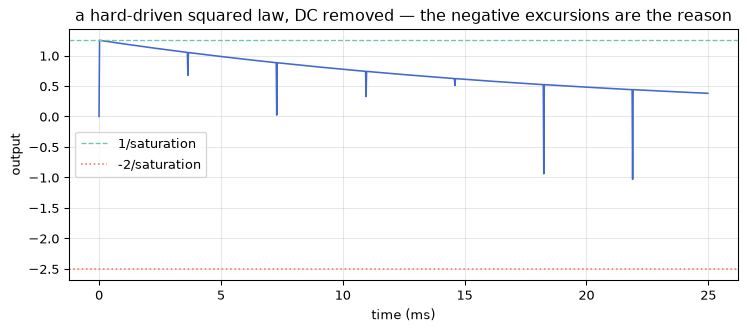

In [6]:
sat = 0.8
drv = tap.Transducer(sr, drive=200.0, asymmetry=1.0, saturation=sat)
n = int(sr * 1.0)
y = drv.process(np.sin(2 * np.pi * 137.0 * np.arange(n) / sr))
print(f"drive 200, asymmetry 1, saturation {sat}")
print(f"  the naive bound 1/saturation : {1/sat:.3f}")
print(f"  the real bound  2/saturation : {2/sat:.3f}")
print(f"  measured peak                : {np.abs(y).max():.3f}")

fig, ax = plt.subplots()
ax.plot(np.arange(1200) / sr * 1000, y[:1200], color=C[0], lw=1.2)
ax.axhline(1 / sat, color=C[3], ls="--", lw=1.0, label="1/saturation")
ax.axhline(-2 / sat, color=C[2], ls=":", lw=1.2, label="-2/saturation")
ax.set_xlabel("time (ms)"); ax.set_ylabel("output")
ax.set_title("a hard-driven squared law, DC removed — the negative excursions are the reason")
ax.legend()
plt.show()

## 4 · The palme: twelve strings, and what they answer

The peer-reviewed source says **twelve** strings; widely copied hobbyist build pages say
twenty-four. This kernel follows the peer-reviewed source. Their *tuning* is not published
anywhere found, so it is a parameter — chromatic across an octave by default, so the halo answers
whatever you play, or the harmonic series on the root, which answers one key.

Below: sweep a faded drive tone across two octaves and measure the ring left behind after the
drive stops. The twelve strings show up as peaks, and so do their harmonics.

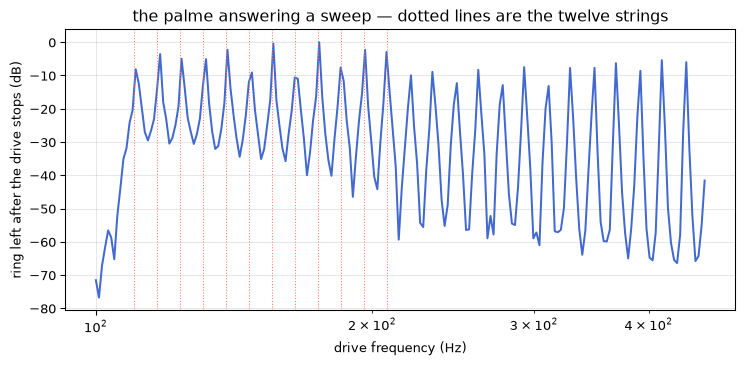

In [7]:
def ring_after(harp_kwargs, hz, drive_s=2.0, tail_s=1.0, fade_s=0.25):
    # The drive is faded in and out. Switching a tone on and off is a step, and a step excites
    # every string on the board — without the fades this measures its own edges, not sympathy.
    p = tap.Palme(sr, **harp_kwargs)
    n_on = int(sr * drive_s)
    n = n_on + int(sr * tail_s)
    t = np.arange(n) / sr
    g = np.zeros(n)
    f = int(sr * fade_s)
    g[:n_on] = 1.0
    g[:f] = 0.5 - 0.5 * np.cos(np.pi * np.arange(f) / f)
    g[n_on - f:n_on] = 0.5 - 0.5 * np.cos(np.pi * np.arange(f, 0, -1) / f)
    y = p.process(g * 0.3 * np.sin(2 * np.pi * hz * t))
    tail = y[n_on + int(sr * 0.2):]
    return float(np.sqrt(np.mean(tail ** 2)))

kw = dict(root_hz=110.0, tuning=0, decay=6.0, damping=4000.0, detune=0.0,
          drive=1.0, asymmetry=0.0, saturation=0.0, mix=100.0, level=1.0, smooth_ms=0.0)
probe = np.geomspace(100.0, 460.0, 200)
tails = np.array([ring_after(kw, f) for f in probe])

strings_hz, strings_fb = tap.Palme(sr, **kw).strings()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.semilogx(probe, 20 * np.log10(tails / tails.max()), color=C[0], lw=1.5)
for f in strings_hz:
    ax.axvline(f, color=C[2], lw=0.8, ls=":", alpha=0.9)
ax.set_xlabel("drive frequency (Hz)"); ax.set_ylabel("ring left after the drive stops (dB)")
ax.set_title("the palme answering a sweep — dotted lines are the twelve strings")
plt.show()

In [8]:
# Selectivity, string by string: the ring on the note against the ring a quarter-tone sharp of it,
# which is neither any string's fundamental nor any string's harmonic.
print(f"{'string':>7} {'Hz':>8} {'on note':>10} {'+50 cents':>11} {'ratio':>9}")
ratios = []
for i in range(12):
    f = 110.0 * 2 ** (i / 12)
    on = ring_after(kw, f)
    off = ring_after(kw, 110.0 * 2 ** ((i + 0.5) / 12))
    ratios.append(on / off)
    print(f"{i:7d} {f:8.2f} {on:10.4f} {off:11.4f} {on/off:9.1f}")
print(f"\nworst selectivity across the board: {min(ratios):.1f}x")
print("It climbs steeply with pitch, and that is physics rather than a defect: at a fixed ring")
print("time a loop's Q scales with f x T60, so the top of the board is far the more selective end.")

 string       Hz    on note   +50 cents     ratio


      0   110.00     0.6329      0.1438       4.4


      1   116.54     0.6917      0.1548       4.5


      2   123.47     0.7431      0.1069       7.0


      3   130.81     0.7842      0.1170       6.7


...

      7   164.81     1.8316      0.0427      42.9


      8   174.61     2.6112      0.0336      77.7


      9   185.00     3.4817      0.0164     212.6


     10   196.00     4.1742      0.0067     618.8


     11   207.65     4.3352      0.0039    1121.9

worst selectivity across the board: 4.4x
It climbs steeply with pitch, and that is physics rather than a defect: at a fixed ring
time a loop's Q scales with f x T60, so the top of the board is far the more selective end.


## 5 · Ring time and damping are not independent

A string's loop gain is derived from the ring time you ask for and then compensated for what the
in-loop damping filter and DC blocker take out at the fundamental — so the stated ring time is the
ring time you get, at any damping setting **until the compensation runs out of headroom**. The
loop gain is capped just under unity to keep the loop strictly contractive, and past that point
damping wins and the string rings for less than you asked.

That is an honest limit rather than a bug, and it is visible directly in the loop gains:

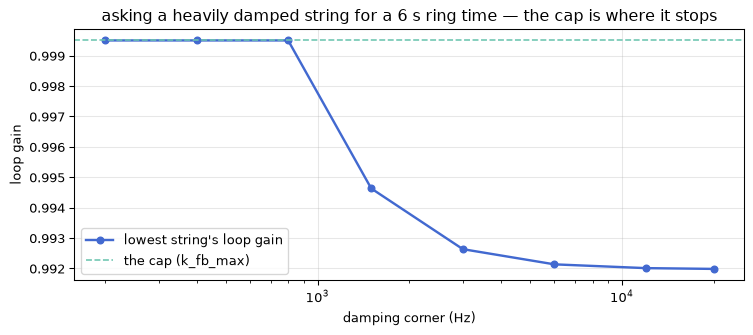

pinned at the cap below about 800 Hz of damping


In [9]:
damps = np.array([200.0, 400.0, 800.0, 1500.0, 3000.0, 6000.0, 12000.0, 20000.0])
fb0 = []
for d in damps:
    p = tap.Palme(sr, root_hz=110.0, tuning=0, decay=6.0, damping=float(d), detune=0.0)
    fb0.append(p.strings()[1][0])
fb0 = np.array(fb0)

fig, ax = plt.subplots()
ax.semilogx(damps, fb0, "o-", color=C[0], lw=1.8, ms=5, label="lowest string's loop gain")
ax.axhline(0.9995, color=C[3], lw=1.2, ls="--", label="the cap (k_fb_max)")
ax.set_xlabel("damping corner (Hz)"); ax.set_ylabel("loop gain")
ax.set_title("asking a heavily damped string for a 6 s ring time — the cap is where it stops")
ax.legend()
plt.show()

pinned = damps[fb0 >= 0.9995]
print(f"pinned at the cap below about {pinned.max():.0f} Hz of damping" if len(pinned)
      else "never reaches the cap at this ring time")

## 6 · The order is the argument

The electrical signal reaches the transducer first, and the transducer's motion is what excites
the body. So the nonlinearity sits **upstream** of the resonator. That is not a cosmetic choice:
driving a distorted waveform into a gong is a different sound from distorting a gong, because the
body filters the harmonics the driver made rather than the driver making harmonics out of the
body's ringing.

The kernel's Catch2 suite pins this as a null test — a hand-wired `transducer` → `plate` matches
the machine bitwise, and the reversed wiring does not. Here is the same comparison as a spectrum.

cabinet vs hand-wired driver -> body : 0.000e+00
cabinet vs hand-wired body -> driver : 2.335e-03
signal peak, for scale               : 0.0084
so the reversed wiring differs by     : 28% of peak


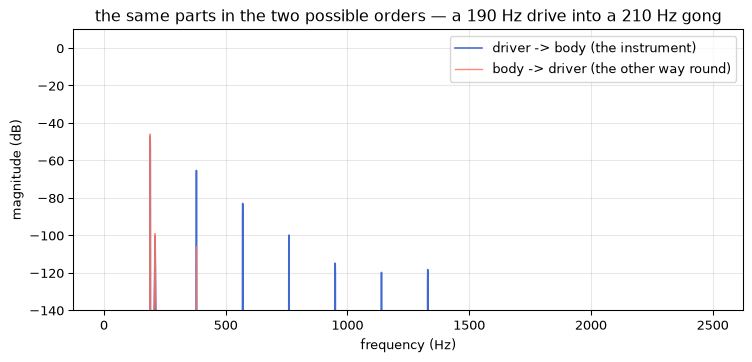

In [10]:
n = int(sr * 3.0)
t = np.arange(n) / sr
x = 0.5 * np.sin(2 * np.pi * 190.0 * t)

BODY = dict(pitch_hz=210.0, decay=3.0, brightness=0.8)
DRV  = dict(drive=1.7, asymmetry=0.4, saturation=0.9)

y_fwd = tap.Plate(sr, **BODY).process(tap.Transducer(sr, **DRV).process(x))  # the instrument
y_rev = tap.Transducer(sr, **DRV).process(tap.Plate(sr, **BODY).process(x))  # the other way round

# The composed cabinet must BE the forward wiring — the kernel's own null test, repeated here
# through the C ABI rather than through C++.
cab = tap.Metallique(sr, mix=100.0, level=1.0, smooth_ms=0.0, **BODY, **DRV)
y_cab = cab.process(x)
print(f"cabinet vs hand-wired driver -> body : {np.max(np.abs(y_cab - y_fwd)):.3e}")
print(f"cabinet vs hand-wired body -> driver : {np.max(np.abs(y_cab - y_rev)):.3e}")
peak = np.max(np.abs(y_cab))
print(f"signal peak, for scale               : {peak:.4f}")
print(f"so the reversed wiring differs by     : {100 * np.max(np.abs(y_cab - y_rev)) / peak:.0f}% of peak")

f_f, m_f = spectrum(y_fwd)
f_r, m_r = spectrum(y_rev)
keep = f_f <= 2500

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(f_f[keep], 20 * np.log10(m_f[keep] + 1e-12), color=C[0], lw=1.2,
        label="driver -> body (the instrument)")
ax.plot(f_r[keep], 20 * np.log10(m_r[keep] + 1e-12), color=C[2], lw=1.0, alpha=0.85,
        label="body -> driver (the other way round)")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("magnitude (dB)")
ax.set_title("the same parts in the two possible orders — a 190 Hz drive into a 210 Hz gong")
ax.set_ylim(-140, 10); ax.legend()
plt.show()

## What this notebook cannot tell you

Everything above measures the kernel against its own stated maths. None of it measures the kernel
against Martenot's instruments, because no source found gives modal data for either body. The
mode ratios are the general physics of free circular plates and of strings; the string tuning is a
design choice; and the transducer's two nonlinear coefficients are voiced by ear, since the source
establishes *that* the moving-iron driver is nonlinear without handing over a curve.

So: **a recreation**, labelled as one in the header, in the plan, and here. What is honest about
it is the arithmetic — unit peak gain per mode, weights summing to one, the ring time you ask for,
the published ratios coming back out, and a bound that is stated correctly rather than
optimistically.

Also not modelled, and stated in the header: radiation and directivity, the soundboard's own
resonance, and string stiffness (a real steel string's partials stretch sharp; a plain delay
loop's are exactly harmonic).